# 2. Regression Modeling

This notebook covers:
- Regression model building.
- Training and evaluation (RMSE, MAE, R²).
- Hyperparameter tuning.

Dataset shape: (10000, 15)
      category   price  quantity delivery_status payment_method device_type  \
0        Books   45.95         4         Shipped         PayPal      Mobile   
1  Electronics  403.17         3       Delivered         PayPal      Mobile   
2       Beauty  317.45         2         Shipped    Credit Card      Mobile   
3         Home   24.08         3         Shipped         PayPal      Tablet   
4     Clothing  494.90         1       Delivered         PayPal      Tablet   

       channel customer_segment  order_month  order_day  order_hour  \
0  Paid Search              VIP            4         20          14   
1  Paid Search        Returning            4         20          14   
2        Email        Returning            4         20          14   
3       Social              VIP            4         20          14   
4      Organic              VIP            4         20          14   

   shipping_month  shipping_day  shipping_hour  shipping_delay  
0     

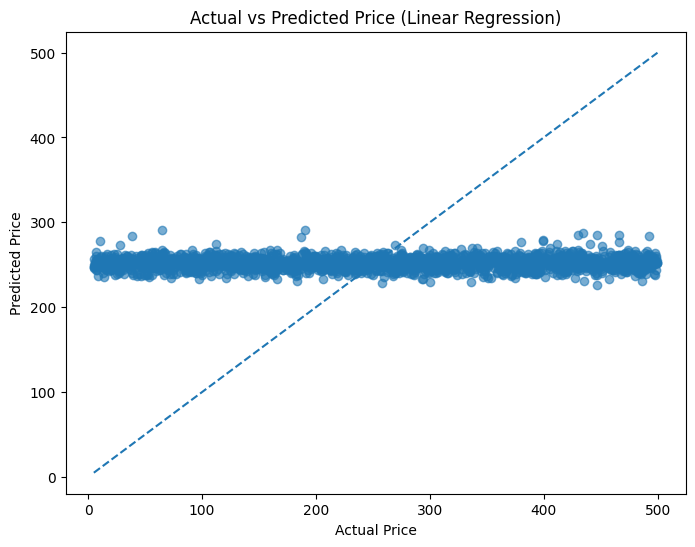


===== SAMPLE PREDICTIONS =====
   Actual Price  Predicted Price
0        432.96       255.289196
1        352.49       254.800760
2        315.73       252.976427
3        214.16       244.815529
4         52.33       254.641062
5        394.88       254.098776
6        353.01       255.115998
7        389.93       250.372860
8        226.72       261.467786
9        149.03       248.237567


In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =====================================================
# 1. LOAD CLEANED DATA
# =====================================================
df = pd.read_csv("../data/cleaned_data.csv")

print("Dataset shape:", df.shape)
print(df.head())

# =====================================================
# 2. DEFINE FEATURES AND TARGET
# =====================================================
X = df.drop("price", axis=1)
y = df["price"]

# =====================================================
# 3. TRAIN-TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================================
# 4. IDENTIFY COLUMN TYPES
# =====================================================
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object", "string"]).columns.tolist()

print("\nCategorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

# =====================================================
# 5. PREPROCESSING PIPELINE
# =====================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# =====================================================
# 6. MODEL 1 - LINEAR REGRESSION
# =====================================================
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred_lr = linear_model.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n===== LINEAR REGRESSION RESULTS =====")
print("MSE :", mse_lr)
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)

# =====================================================
# 7. MODEL 2 - RANDOM FOREST REGRESSOR
# =====================================================
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

# =====================================================
# 8. HYPERPARAMETER TUNING FOR RANDOM FOREST
# =====================================================
param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [10, 20, None],
    "regressor__min_samples_split": [2, 5],
    "regressor__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters for Random Forest:")
print(grid_search.best_params_)

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n===== RANDOM FOREST RESULTS =====")
print("MSE :", mse_rf)
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

# =====================================================
# 9. CROSS VALIDATION
# =====================================================
cv_scores_lr = cross_val_score(
    linear_model, X, y, cv=5, scoring="neg_mean_squared_error"
)
cv_rmse_lr = np.sqrt(-cv_scores_lr)

cv_scores_rf = cross_val_score(
    best_rf, X, y, cv=5, scoring="neg_mean_squared_error"
)
cv_rmse_rf = np.sqrt(-cv_scores_rf)

print("\n===== CROSS VALIDATION =====")
print("Linear Regression RMSE values:", cv_rmse_lr)
print("Linear Regression Mean RMSE :", cv_rmse_lr.mean())

print("\nRandom Forest RMSE values:", cv_rmse_rf)
print("Random Forest Mean RMSE :", cv_rmse_rf.mean())

# =====================================================
# 10. MODEL COMPARISON TABLE
# =====================================================
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Test MSE": [mse_lr, mse_rf],
    "Test MAE": [mae_lr, mae_rf],
    "Test RMSE": [rmse_lr, rmse_rf],
    "Test R2": [r2_lr, r2_rf],
    "CV Mean RMSE": [cv_rmse_lr.mean(), cv_rmse_rf.mean()]
})

print("\n===== MODEL COMPARISON =====")
print(comparison)

# =====================================================
# 11. SELECT BEST MODEL
# =====================================================
if rmse_lr < rmse_rf:
    final_model = linear_model
    best_model_name = "Linear Regression"
    final_predictions = y_pred_lr
else:
    final_model = best_rf
    best_model_name = "Random Forest"
    final_predictions = y_pred_rf

print("\nBest Model Selected:", best_model_name)

# =====================================================
# 12. ACTUAL VS PREDICTED PLOT
# =====================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, final_predictions, alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Price ({best_model_name})")

min_val = min(y_test.min(), final_predictions.min())
max_val = max(y_test.max(), final_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

# =====================================================
# 13. SAMPLE PREDICTIONS
# =====================================================
results_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": final_predictions
})

print("\n===== SAMPLE PREDICTIONS =====")
print(results_df.head(10))

